# 🍎 Food Ingredient Scanner — Full ML Pipeline
### Scan a food packet → Read ingredients → Explain them → Score health (A–E)

**Pipeline:**
1. Data loading & cleaning (Open Food Facts)
2. Build ingredient vocabulary + additive knowledge base
3. Train LightGBM health classifier
4. OCR + parsing + fuzzy matching + health scoring
5. Scan any image — fully automatic, zero user input

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, json, joblib
from collections import Counter

print("Core libraries loaded ✓")

Core libraries loaded ✓


## Part 1: Data Loading & Cleaning
### Cell 1 — Load the Open Food Facts dataset (163 → 20 columns)

In [2]:
cols = [
    "code", "product_name", "brands",
    "ingredients_text", "additives_n", "additives_tags",
    "nutrition_grade_fr", "nutrition-score-fr_100g",
    "energy_100g", "fat_100g", "saturated-fat_100g",
    "carbohydrates_100g", "sugars_100g", "fiber_100g",
    "proteins_100g", "salt_100g", "sodium_100g",
    "fruits-vegetables-nuts_100g",
    "categories_tags", "countries_en",
]

# ========== CHANGE THIS PATH TO YOUR LOCAL FILE ==========
tsv_path = r"D:\nutri_score\en.openfoodfacts.org.products.tsv.zip"
# ==========================================================

df = pd.read_csv(
    tsv_path,
    sep="\t",
    usecols=lambda c: c in cols,
    low_memory=False,
)

print(f"Raw dataset: {df.shape}")
print(f"\nMissingness per column:")
print(df.isna().mean().sort_values())

Raw dataset: (356027, 20)

Missingness per column:
code                           0.000073
countries_en                   0.000772
product_name                   0.049187
brands                         0.081595
energy_100g                    0.170380
proteins_100g                  0.173768
salt_100g                      0.186188
sodium_100g                    0.186315
ingredients_text               0.202608
additives_n                    0.202681
fat_100g                       0.214956
carbohydrates_100g             0.215734
sugars_100g                    0.215829
saturated-fat_100g             0.258980
nutrition_grade_fr             0.284167
nutrition-score-fr_100g        0.284167
fiber_100g                     0.380151
additives_tags                 0.521977
categories_tags                0.709924
fruits-vegetables-nuts_100g    0.990933
dtype: float64


### Cell 2 — Drop unusable rows + range checks

In [3]:
# 1. Drop the 99%-empty column
df = df.drop(columns=["fruits-vegetables-nuts_100g"], errors="ignore")

# 2. Keep only rows that have BOTH ingredients and a health label
df = df.dropna(subset=["ingredients_text", "nutrition_grade_fr"])

# 3. Deduplicate barcodes
df = df.drop_duplicates(subset="code")

# 4. Fix impossible nutrient values
nutrient_cols = ["energy_100g", "fat_100g", "saturated-fat_100g",
                 "carbohydrates_100g", "sugars_100g", "fiber_100g",
                 "proteins_100g", "salt_100g", "sodium_100g"]

for c in nutrient_cols:
    if c == "energy_100g":
        df = df[(df[c].between(0, 4000)) | df[c].isna()]
    else:
        df = df[(df[c].between(0, 100)) | df[c].isna()]

# 5. Normalize the label
df["nutrition_grade_fr"] = df["nutrition_grade_fr"].str.lower().str.strip()
df = df[df["nutrition_grade_fr"].isin(list("abcde"))]

print(f"After basic cleaning: {df.shape}")
print(df["nutrition_grade_fr"].value_counts())

After basic cleaning: (229974, 19)
nutrition_grade_fr
d    65482
c    47596
e    45223
a    36692
b    34981
Name: count, dtype: int64


### Cell 3 — Explore distributions

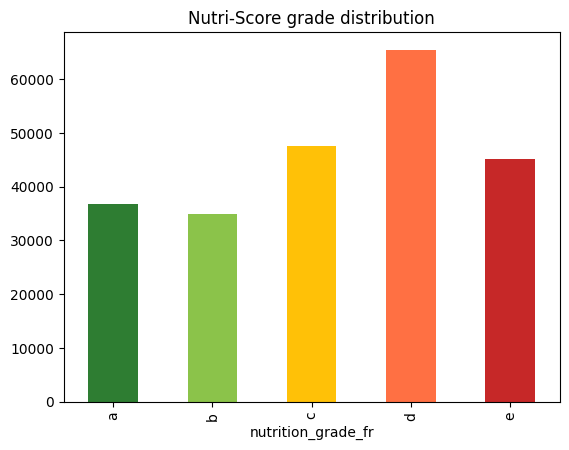

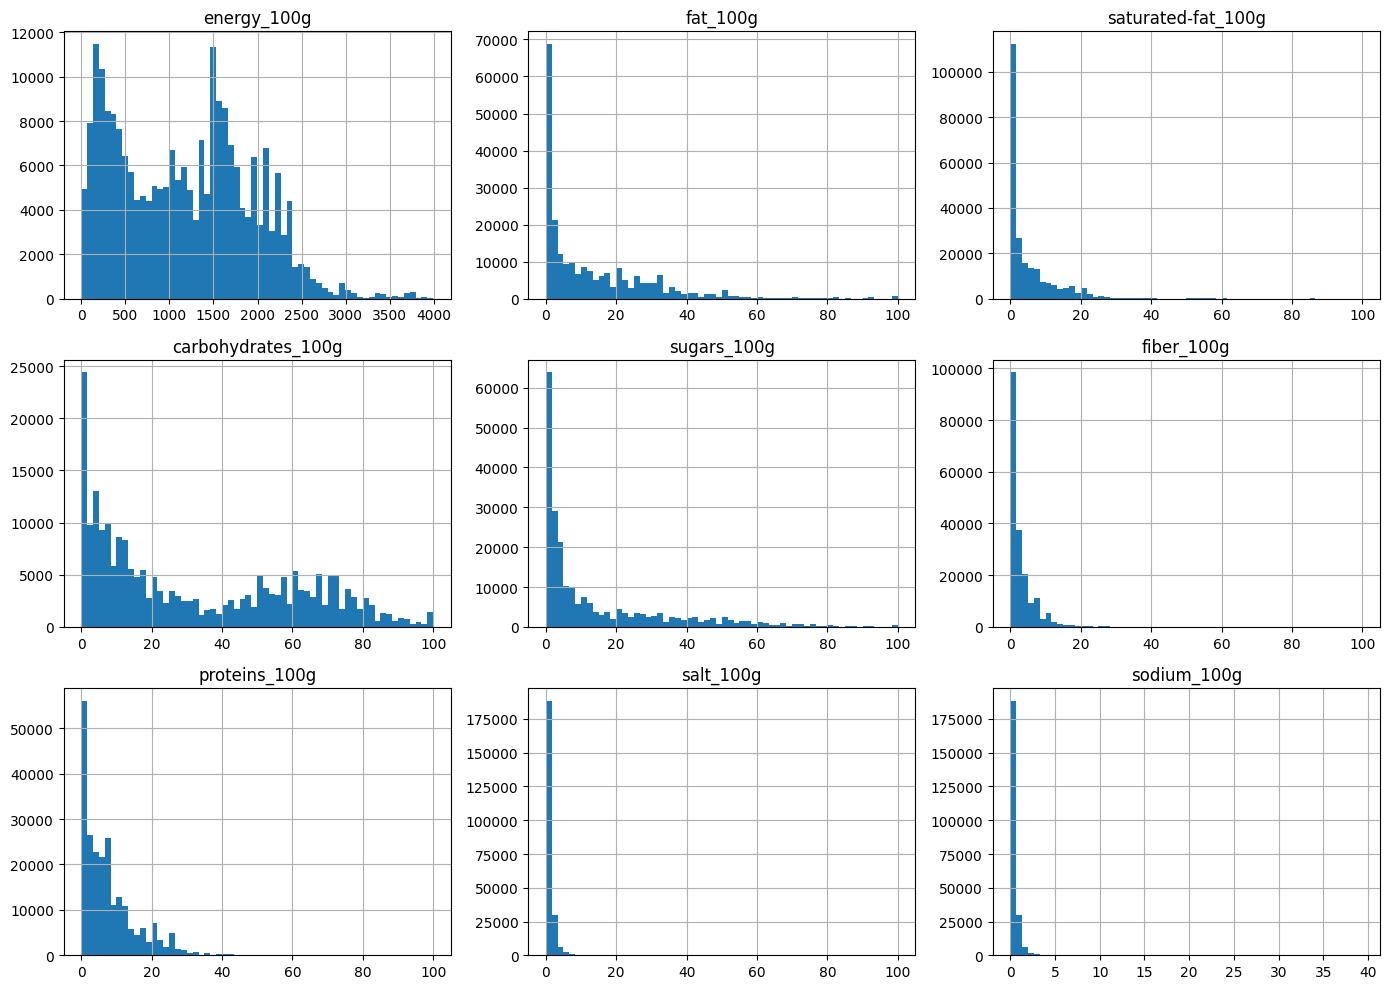

,count,mean,std,min,25%,50%,75%,max
energy_100g,229818.0,1170.981221,762.279411,0.0,448.00000,1176.000,1703.00000,3992.000000
fat_100g,228932.0,13.324481,16.264087,0.0,0.83000,7.100,21.43000,100.000000
saturated-fat_100g,229818.0,4.883401,7.418021,0.0,0.00000,1.790,7.06000,100.000000
carbohydrates_100g,228917.0,32.538509,28.311864,0.0,6.67000,22.700,58.20000,100.000000
sugars_100g,229818.0,14.811930,19.747578,0.0,1.20000,5.000,22.58000,100.000000
fiber_100g,191719.0,2.867694,4.496574,0.0,0.00000,1.600,3.60000,100.000000
proteins_100g,229818.0,7.781614,8.164429,0.0,1.76000,5.600,10.80000,100.000000
salt_100g,229818.0,1.227695,3.974726,0.0,0.10000,0.635,1.36144,100.000000
sodium_100g,229818.0,0.483345,1.564850,0.0,0.03937,0.250,0.53600,39.370079


In [4]:
# Grade distribution
df["nutrition_grade_fr"].value_counts().sort_index().plot(
    kind="bar", color=["#2e7d32","#8bc34a","#ffc107","#ff7043","#c62828"])
plt.title("Nutri-Score grade distribution")
plt.show()

# Nutrient distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.flat, nutrient_cols):
    df[c].dropna().hist(bins=60, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

df[nutrient_cols].describe().T

### Cell 4 — Cross-column consistency checks

In [5]:
checks = {
    "sugar > carbs": df["sugars_100g"] > df["carbohydrates_100g"] + 1,
    "satfat > fat": df["saturated-fat_100g"] > df["fat_100g"] + 1,
    "macros > 105g": (df["fat_100g"].fillna(0)
                      + df["carbohydrates_100g"].fillna(0)
                      + df["proteins_100g"].fillna(0)) > 105,
    "salt/sodium mismatch": (
        df["salt_100g"].notna() & df["sodium_100g"].notna() &
        ((df["salt_100g"] - df["sodium_100g"] * 2.5).abs() > 1)
    ),
}

for name, mask in checks.items():
    print(f"{name:25s} {mask.sum():>7,} rows")

bad = np.zeros(len(df), dtype=bool)
for mask in checks.values():
    bad |= mask.fillna(False).values
print(f"\nTotal inconsistent rows: {bad.sum():,}")
df = df[~bad]
print("Remaining:", df.shape)

sugar > carbs                 456 rows
satfat > fat                  180 rows
macros > 105g                 628 rows
salt/sodium mismatch          267 rows

Total inconsistent rows: 1,521
Remaining: (228453, 19)


### Cell 5 — Energy cross-check (energy ≈ fat×37 + carbs×17 + protein×17)

In [6]:
est = (df["fat_100g"].fillna(0) * 37
       + df["carbohydrates_100g"].fillna(0) * 17
       + df["proteins_100g"].fillna(0) * 17)

has_macros = df[["fat_100g","carbohydrates_100g","proteins_100g"]].notna().all(axis=1)
dev = (df["energy_100g"] - est).abs()

bad_energy = has_macros & df["energy_100g"].notna() & (dev > est.clip(lower=200) * 0.30)
print("Energy-inconsistent rows:", bad_energy.sum())
df = df[~bad_energy]
print("Remaining:", df.shape)

Energy-inconsistent rows: 4586
Remaining: (223867, 19)


### Cell 6 — Ingredient text quality + language/country filter

In [7]:
# --- Text quality ---
txt = df["ingredients_text"].astype(str)
df["ing_len"] = txt.str.len()
df["ing_n_commas"] = txt.str.count(",")

junk = (df["ing_len"] < 6) | ((df["ing_n_commas"] == 0) & (df["ing_len"] > 200))
print("Junk ingredient texts:", junk.sum())
df = df[~junk]

non_latin_ratio = txt.str.count(r"[^\x00-\x7F]") / df["ing_len"].clip(lower=1)
df["non_latin_ratio"] = non_latin_ratio
print("Rows >50% non-ASCII chars:", (df["non_latin_ratio"] > 0.5).sum())
df = df[df["non_latin_ratio"] <= 0.5]
print("After text cleaning:", df.shape)

# --- Country filter ---
print("\nTop countries:")
print(df["countries_en"].value_counts().head(10))

keep = df["countries_en"].fillna("").str.contains(
    "United States|United Kingdom|India|Canada|Australia|Ireland", case=False)
df = df[keep]
print(f"\nAfter country filter: {df.shape}")

# --- Near-duplicates ---
dupe_mask = df.duplicated(subset=["product_name", "brands", "ingredients_text"], keep="first")
print(f"Near-duplicate products: {dupe_mask.sum()}")
df = df[~dupe_mask]

# --- Drop helper columns ---
df = df.drop(columns=["ing_len", "ing_n_commas", "non_latin_ratio"], errors="ignore")
print(f"\nFinal clean dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Junk ingredient texts: 1573
Rows >50% non-ASCII chars: 59
After text cleaning: (222235, 22)

Top countries:
countries_en
United States         134899
France                 66610
Switzerland             5708
Germany                 4249
Spain                   2418
United Kingdom          1302
France,Switzerland      1059
Belgium,France           565
Australia                410
Belgium                  376
Name: count, dtype: int64

After country filter: (137550, 22)
Near-duplicate products: 2973

Final clean dataset: (134577, 19)
Columns: ['code', 'product_name', 'brands', 'categories_tags', 'countries_en', 'ingredients_text', 'additives_n', 'additives_tags', 'nutrition_grade_fr', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'nutrition-score-fr_100g']


### Cell 7 — Final sanity check (correlations must match nutrition science)

=== Grade Balance ===
nutrition_grade_fr
a    20844
b    20983
c    26845
d    39386
e    26519
Name: count, dtype: int64

nutrition_grade_fr
a    0.155
b    0.156
c    0.199
d    0.293
e    0.197
Name: proportion, dtype: float64

=== Missingness ===
additives_n           0.000
energy_100g           0.001
proteins_100g         0.001
saturated-fat_100g    0.001
salt_100g             0.001
sugars_100g           0.001
sodium_100g           0.001
carbohydrates_100g    0.001
fat_100g              0.002
fiber_100g            0.033
dtype: float64

=== Correlation with grade (positive = more → worse grade) ===
saturated-fat_100g    0.605
energy_100g           0.601
fat_100g              0.539
sugars_100g           0.442
carbohydrates_100g    0.249
salt_100g             0.175
sodium_100g           0.175
additives_n           0.169
proteins_100g         0.112
fiber_100g           -0.149
Name: grade_num, dtype: float64


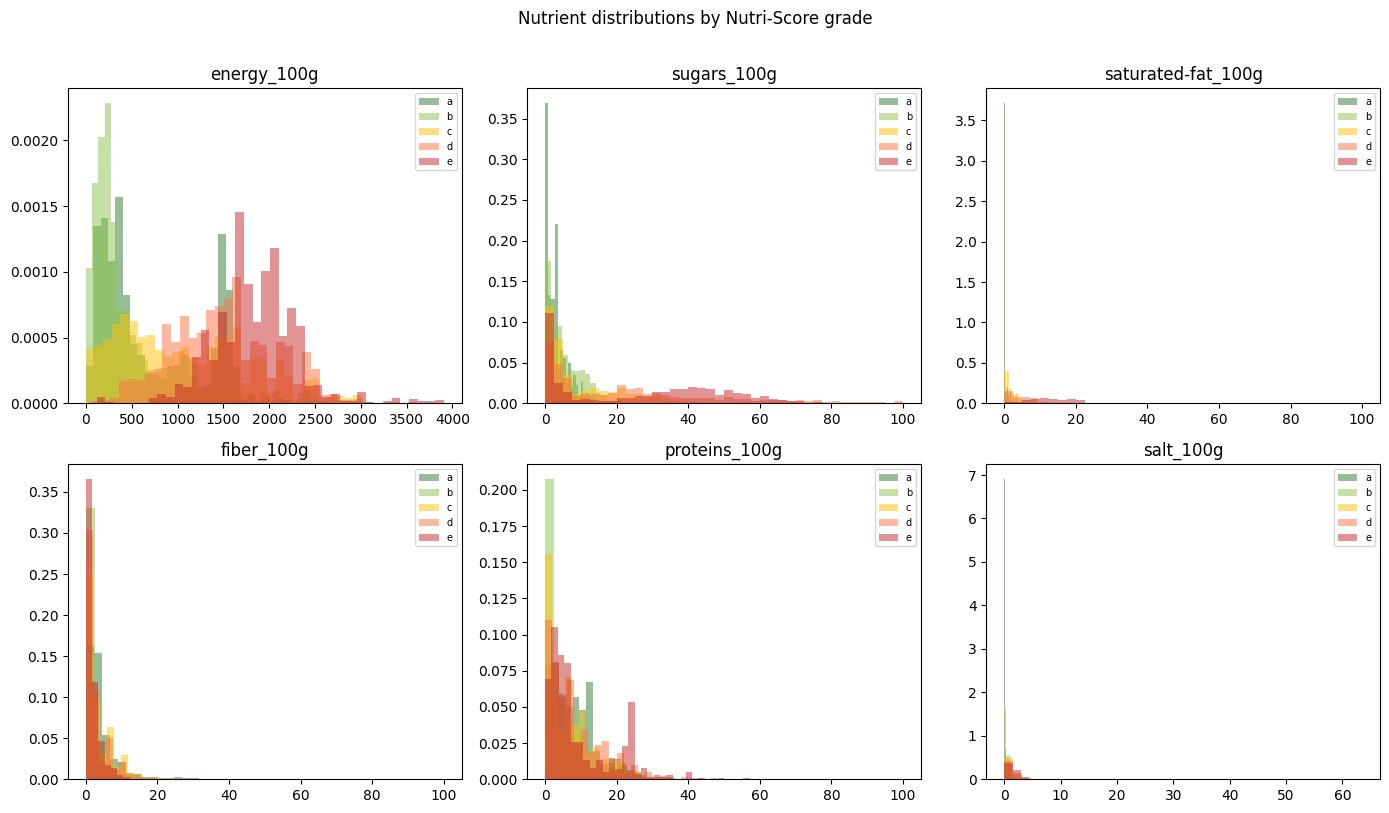

In [8]:
print("=== Grade Balance ===")
print(df["nutrition_grade_fr"].value_counts().sort_index())
print()
print(df["nutrition_grade_fr"].value_counts(normalize=True).sort_index().round(3))

print("\n=== Missingness ===")
print(df[nutrient_cols + ["additives_n"]].isna().mean().sort_values().round(3))

df["grade_num"] = df["nutrition_grade_fr"].map({"a":1,"b":2,"c":3,"d":4,"e":5})

print("\n=== Correlation with grade (positive = more → worse grade) ===")
corr = df[nutrient_cols + ["additives_n", "grade_num"]].corr()["grade_num"].drop("grade_num")
print(corr.sort_values(ascending=False).round(3))

# Visual check
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = ["energy_100g", "sugars_100g", "saturated-fat_100g",
             "fiber_100g", "proteins_100g", "salt_100g"]
colors = ["#2e7d32","#8bc34a","#ffc107","#ff7043","#c62828"]
for ax, col in zip(axes.flat, plot_cols):
    for i, grade in enumerate(["a","b","c","d","e"]):
        vals = df[df["nutrition_grade_fr"] == grade][col].dropna()
        ax.hist(vals, bins=40, alpha=0.5, color=colors[i], label=grade, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle("Nutrient distributions by Nutri-Score grade", y=1.01)
plt.tight_layout()
plt.show()

df = df.drop(columns=["grade_num"])

### Cell 8 — Save clean dataset

In [9]:
df.to_csv("off_clean.csv", index=False)

print("=" * 45)
print("  CLEAN DATASET SUMMARY")
print("=" * 45)
print(f"  Rows            : {len(df):,}")
print(f"  Columns         : {df.shape[1]}")
print(f"  Grade balance   : {df['nutrition_grade_fr'].value_counts(normalize=True).sort_index().round(3).to_dict()}")
print(f"  Max missing     : {df[nutrient_cols].isna().mean().max():.1%} (fiber)")
print("=" * 45)
print("Saved → off_clean.csv")

  CLEAN DATASET SUMMARY
  Rows            : 134,577
  Columns         : 19
  Grade balance   : {'a': 0.155, 'b': 0.156, 'c': 0.199, 'd': 0.293, 'e': 0.197}
  Max missing     : 3.3% (fiber)
Saved → off_clean.csv


---
## Part 2: Build Vocabulary, Additive KB, and Classifier

### Cell 9 — Build ingredient vocabulary

In [10]:
def tokenize_ingredients(text):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]|\(.*?\)", "", text)
    parts = re.split(r"[,;]", text)
    cleaned = []
    for p in parts:
        p = p.strip(" .:*%0123456789-_/\\")
        if 3 <= len(p) <= 50 and not p.replace(" ","").isdigit():
            cleaned.append(p)
    return cleaned

print("Building vocabulary from full clean dataset...")
ingredient_counter = Counter()
for text in df["ingredients_text"]:
    ingredient_counter.update(tokenize_ingredients(text))

vocab = {ing: count for ing, count in ingredient_counter.items() if count >= 30}
print(f"Raw unique tokens : {len(ingredient_counter):,}")
print(f"After freq filter : {len(vocab):,}  (appeared in 30+ products)")

print("\nTop 30 ingredients:")
for ing, n in sorted(vocab.items(), key=lambda x: -x[1])[:30]:
    print(f"  {n:>7,}  {ing}")

with open("ingredient_vocab.json", "w") as f:
    json.dump(vocab, f)
print("\nSaved → ingredient_vocab.json")

Building vocabulary from full clean dataset...
Raw unique tokens : 84,417
After freq filter : 2,663  (appeared in 30+ products)

Top 30 ingredients:
   53,094  salt
   46,928  sugar
   40,754  water
   15,564  citric acid
   13,634  corn syrup
   11,496  sea salt
    9,418  spices
    9,150  natural flavor
    8,521  dextrose
    8,405  soybean oil
    7,521  soy lecithin
    6,929  xanthan gum
    6,478  high fructose corn syrup
    6,433  garlic
    6,402  natural flavors
    6,356  whey
    6,225  vegetable oil
    6,158  maltodextrin
    5,701  yeast
    5,060  cream
    5,050  guar gum
    4,855  wheat flour
    4,483  modified corn starch
    4,431  corn starch
    4,426  garlic powder
    4,424  palm oil
    4,362  vinegar
    4,347  carrageenan
    4,330  onion powder
    4,194  butter

Saved → ingredient_vocab.json


### Cell 10 — Build E-number / additive knowledge base

In [11]:
additive_rows = []
for _, row in df[["additives_tags","nutrition_grade_fr"]].dropna(subset=["additives_tags"]).iterrows():
    for tag in str(row["additives_tags"]).split(","):
        tag = tag.strip().replace("en:","").upper()
        if re.match(r"E\d{3}", tag):
            additive_rows.append({
                "code": tag,
                "grade": row["nutrition_grade_fr"]
            })

additives_df = pd.DataFrame(additive_rows)
additive_summary = (additives_df.groupby("code")
                    .agg(
                        count=("code", "count"),
                        most_common_grade=("grade", lambda x: x.value_counts().index[0])
                    )
                    .sort_values("count", ascending=False)
                    .reset_index())

print(f"Unique E-numbers found: {len(additive_summary)}")
print(additive_summary.head(20).to_string(index=False))

additive_summary.to_csv("additives_kb.csv", index=False)
print("\nSaved → additives_kb.csv")

Unique E-numbers found: 347
  code  count most_common_grade
  E330  22420                 d
  E375  20680                 d
  E101  20484                 d
 E101I  20472                 d
  E322  17615                 e
 E322I  17533                 e
  E415   8956                 d
  E412   7458                 d
  E339   7147                 d
  E300   6131                 b
  E407   5939                 d
  E471   5467                 d
 E150A   5238                 d
  E129   5219                 d
  E410   4889                 d
  E500   4836                 d
E500II   4532                 d
  E202   4526                 d
  E341   4479                 d
  E102   4403                 d

Saved → additives_kb.csv


### Cell 11 — Train the LightGBM health classifier

Train: (107661, 10)  Test: (26916, 10)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2293
[LightGBM] [Info] Number of data points in the train set: 107661, number of used features: 10
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.185231
[200]	valid_0's multi_logloss: 0.11558
[300]	valid_0's multi_logloss: 0.0956802
Early stopping, best iteration is:
[308]	valid_0's multi_logloss: 0.0954176

               precision    recall  f1-score   support

           a       0.99

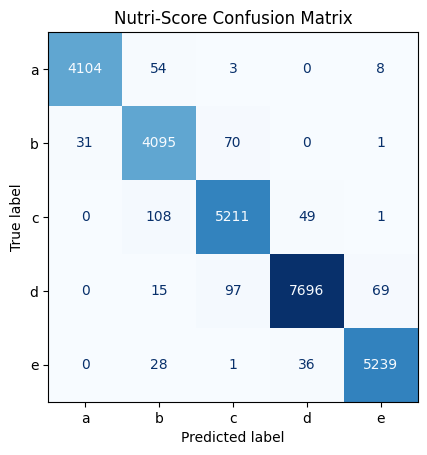


Feature Importance:
  salt_100g                 ██████████████████████████████ 10051
  sugars_100g               ███████████████████████ 7914
  energy_100g               █████████████████████ 7167
  saturated-fat_100g        ████████████████████ 6701
  fiber_100g                ███████████████████ 6550
  proteins_100g             ████████████ 4157
  carbohydrates_100g        ████ 1544
  fat_100g                  ████ 1356
  sodium_100g               █ 425
  additives_n                335

Saved → health_classifier.pkl


In [12]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

features = nutrient_cols + ["additives_n"]
X = df[features].fillna(-1)
y = df["nutrition_grade_fr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = model.predict(X_test)
print("\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=list("abcde"),
    colorbar=False, cmap="Blues"
)
plt.title("Nutri-Score Confusion Matrix")
plt.show()

# Feature importance
importance = sorted(zip(features, model.feature_importances_), key=lambda x: -x[1])
print("\nFeature Importance:")
for feat, imp in importance:
    bar = "█" * int(imp / max(v for _,v in importance) * 30)
    print(f"  {feat:25s} {bar} {imp}")

joblib.dump(model, "health_classifier.pkl")
print("\nSaved → health_classifier.pkl")

---
## Part 3: Image Scanning Pipeline (Fully Automatic)

**What changed from the old version:**
- Auto-detects whether the image is a Nutrition Facts panel or an Ingredient list
- Automatically extracts nutrient values from OCR text using regex — **no user input needed**
- Falls back to database estimation if nutrients can't be extracted
- Uses `pd.DataFrame` with column names to avoid sklearn warnings

### Cell 12 — Load saved assets + initialize OCR

In [13]:
import json, re, joblib
import numpy as np
import pandas as pd
import cv2
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt
from PIL import Image

# --- Load assets ---
with open("ingredient_vocab.json", "r") as f:
    vocab = json.load(f)
vocab_list = list(vocab.keys())

additives_kb = pd.read_csv("additives_kb.csv")
model = joblib.load("health_classifier.pkl")

# --- Load clean dataset (needed for ingredient-based estimation fallback) ---
df = pd.read_csv("off_clean.csv")

# --- Initialize OCR engine ---
# Try RapidOCR first (CPU-friendly, no CUDA needed)
# Falls back to PaddleOCR if RapidOCR is not installed
try:
    from rapidocr_onnxruntime import RapidOCR
    ocr_engine = RapidOCR()
    OCR_BACKEND = "rapidocr"
except ImportError:
    try:
        from paddleocr import PaddleOCR
        ocr_engine = PaddleOCR(use_angle_cls=True, lang="en", show_log=False)
        OCR_BACKEND = "paddleocr"
    except ImportError:
        import pytesseract
        OCR_BACKEND = "tesseract"

print(f"✓ Vocabulary     : {len(vocab_list):,} ingredients")
print(f"✓ Additives KB   : {len(additives_kb)} E-numbers")
print(f"✓ Classifier     : loaded")
print(f"✓ Clean dataset  : {len(df):,} products (for fallback estimation)")
print(f"✓ OCR engine     : {OCR_BACKEND}")

C:\Users\Plaksha.PLAKSHA111\AppData\Local\Temp\ipykernel_14852\1971835281.py:18: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("off_clean.csv")


✓ Vocabulary     : 2,663 ingredients
✓ Additives KB   : 347 E-numbers
✓ Classifier     : loaded
✓ Clean dataset  : 134,577 products (for fallback estimation)
✓ OCR engine     : rapidocr


### Cell 13 — Image preprocessing

In [14]:
def preprocess_image(image_path):
    """Clean up a food packet photo for OCR."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    original = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.fastNlMeansDenoising(gray, h=15)
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 10
    )

    # Upscale small images
    h, w = thresh.shape
    if max(h, w) < 1000:
        scale = 1000 / max(h, w)
        thresh = cv2.resize(thresh, None, fx=scale, fy=scale,
                           interpolation=cv2.INTER_CUBIC)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[1].imshow(denoised, cmap="gray")
    axes[1].set_title("Grayscale + Denoised")
    axes[2].imshow(thresh, cmap="gray")
    axes[2].set_title("After Adaptive Threshold")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return thresh, original

### Cell 14 — OCR text extraction

In [15]:
def extract_text(image, original):
    """Run OCR on preprocessed image. Supports RapidOCR, PaddleOCR, and Tesseract."""

    # RapidOCR and PaddleOCR need 3-channel input
    if image.ndim == 2:
        image_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        image_bgr = image

    # Run OCR based on available backend
    if OCR_BACKEND == "rapidocr":
        results, _ = ocr_engine(image_bgr)
        detections = results or []
    elif OCR_BACKEND == "paddleocr":
        results = ocr_engine.ocr(image_bgr)
        detections = results[0] if results and results[0] else []
    else:  # tesseract
        pil_img = Image.fromarray(image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY))
        raw = pytesseract.image_to_string(pil_img)
        print(f"\nDetected text via Tesseract")
        print(f"Raw OCR text:\n{raw}")
        return raw, original

    if not detections:
        print("No text detected!")
        return "", original

    lines = []
    annotated = original.copy()

    for detection in detections:
        if OCR_BACKEND == "rapidocr":
            bbox, text, confidence = detection[0], detection[1], float(detection[2])
        else:
            bbox, text, confidence = detection[0], detection[1][0], float(detection[1][1])

        if confidence > 0.5:
            lines.append(text)
            pts = np.array(bbox, dtype=np.int32)
            cv2.polylines(annotated, [pts], True, (0, 255, 0), 2)
            cv2.putText(annotated, f"{text} ({confidence:.0%})",
                       (int(bbox[0][0]), int(bbox[0][1]) - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    raw_text = " ".join(lines)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("OCR Detections (green boxes)")
    plt.axis("off")
    plt.show()

    print(f"\nDetected {len(lines)} text regions")
    print(f"Raw OCR text:\n{raw_text}")

    return raw_text, annotated

### Cell 15 — Detect panel type + Extract nutrients from OCR text

In [16]:
def detect_panel_type(raw_text):
    """Detect whether OCR text is from Nutrition Facts or Ingredient list."""
    text = raw_text.lower()

    nutrition_kw = ["nutrition facts", "calories", "total fat",
                    "serving size", "daily value", "amount per serving"]
    ingredient_kw = ["ingredients:", "contains:", "may contain"]

    n_score = sum(1 for kw in nutrition_kw if kw in text)
    i_score = sum(1 for kw in ingredient_kw if kw in text)

    if n_score >= 2 and i_score >= 1:
        return "both"
    elif n_score >= 2:
        return "nutrition"
    elif i_score >= 1:
        return "ingredients"
    elif text.count(",") > 3:
        return "ingredients"
    else:
        return "unknown"


def parse_nutrition_from_ocr(raw_text):
    """
    Automatically extract nutrient values from Nutrition Facts OCR text.

    Looks for patterns like:
      "Total Fat 12g"     → fat_100g = 12
      "Sugars 5g"         → sugars_100g = 5
      "Calories 245"      → energy_100g = 245 * 4.184 (kcal → kJ)
      "Sodium 210mg"      → sodium_100g = 0.21

    Returns a dict ready for the LightGBM model.
    """
    text = raw_text.lower()

    patterns = {
        "energy_100g":         [r"calories\s*(\d+)", r"energy\s*(\d+)"],
        "fat_100g":            [r"total\s*fat\s*(\d+\.?\d*)\s*g"],
        "saturated-fat_100g":  [r"saturated\s*fat\s*(\d+\.?\d*)\s*g"],
        "carbohydrates_100g":  [r"total\s*carbohydr?a?t?e?s?\s*(\d+\.?\d*)\s*g",
                                r"carbohydr?a?t?e?s?\s*(\d+\.?\d*)"],
        "sugars_100g":         [r"total\s*sugars?\s*(\d+\.?\d*)\s*g?",
                                r"sugars?\s*(\d+\.?\d*)\s*g"],
        "fiber_100g":          [r"(?:dietary\s*)?fiber\s*(\d+\.?\d*)\s*g"],
        "proteins_100g":       [r"prote?a?in\s*(\d+\.?\d*)\s*g"],
        "salt_100g":           [r"salt\s*(\d+\.?\d*)\s*g"],
        "sodium_100g":         [r"sodium\s*(\d+\.?\d*)\s*m?g"],
    }

    extracted = {}
    for col, regexes in patterns.items():
        for pattern in regexes:
            match = re.search(pattern, text)
            if match:
                val = float(match.group(1))

                # Unit conversions
                if col == "energy_100g" and val < 1000:
                    val = val * 4.184  # kcal → kJ
                if col == "sodium_100g" and val > 5:
                    val = val / 1000   # mg → g

                extracted[col] = val
                break

    # Calculate salt from sodium if not found directly
    if "sodium_100g" in extracted and "salt_100g" not in extracted:
        extracted["salt_100g"] = extracted["sodium_100g"] * 2.5

    found = len(extracted)
    print(f"\n{'='*60}")
    print(f"AUTO-EXTRACTED NUTRIENTS ({found}/9 found)")
    print(f"{'='*60}")
    for col, val in extracted.items():
        print(f"  {col:25s} = {val:.2f}")

    if found < 3:
        print("\n  ⚠ Too few nutrients extracted — prediction may be less reliable")

    return extracted

### Cell 16 — Ingredient parsing + fuzzy matching

In [17]:
def parse_ingredients(raw_text):
    """Turn OCR text into clean ingredient tokens + E-numbers."""
    text = raw_text.lower()

    # Find the ingredients section
    for marker in ["ingredients:", "ingredients :", "contains:"]:
        if marker in text:
            text = text[text.index(marker) + len(marker):]
            break

    # Extract E-numbers before removing brackets
    e_numbers = [e.upper() for e in re.findall(r"E\d{3}[a-z]?", text, re.IGNORECASE)]

    # Clean up
    text = re.sub(r"\(?\d+\.?\d*\s*%\)?", "", text)
    text = re.sub(r"\[.*?\]|\(.*?\)", "", text)

    cleaned = []
    for p in re.split(r"[,;.]", text):
        p = p.strip(" :*-_/\\0123456789%")
        p = re.sub(r"^and\s+", "", p)
        if 2 < len(p) <= 50 and not p.replace(" ", "").isdigit():
            cleaned.append(p)

    print(f"\nParsed {len(cleaned)} ingredients + {len(e_numbers)} E-numbers")
    print(f"Ingredients: {cleaned}")
    print(f"E-numbers  : {e_numbers}")

    return cleaned, e_numbers


def match_ingredients(parsed_tokens, vocab_list):
    """Fuzzy-match tokens to ingredient vocabulary."""
    matched, unmatched = [], []

    for token in parsed_tokens:
        result = process.extractOne(
            token, vocab_list, scorer=fuzz.WRatio, score_cutoff=70
        )
        if result:
            name, score, _ = result
            matched.append({
                "ocr_text": token, "matched_to": name,
                "confidence": score, "frequency": vocab.get(name, 0)
            })
        else:
            unmatched.append(token)

    print(f"\n{'='*60}")
    print(f"MATCHED INGREDIENTS ({len(matched)}/{len(parsed_tokens)})")
    print(f"{'='*60}")
    for m in matched:
        exact = "✓ exact" if m["confidence"] == 100 else ""
        print(f"  {m['ocr_text']:30s} → {m['matched_to']:25s} ({m['confidence']:.0f}%) {exact}")
    if unmatched:
        print(f"\nUNMATCHED ({len(unmatched)}):")
        for u in unmatched:
            print(f"  ✗ {u}")

    return matched, unmatched

### Cell 17 — Additive explainer (plain-language lookup table)

In [18]:
ADDITIVE_EXPLANATIONS = {
    "E100":  {"name": "Curcumin", "what": "Yellow coloring from turmeric", "safety": "Generally safe, natural origin"},
    "E101":  {"name": "Riboflavin (Vitamin B2)", "what": "Yellow coloring, also a vitamin", "safety": "Safe — it's a vitamin your body needs"},
    "E102":  {"name": "Tartrazine", "what": "Artificial yellow dye", "safety": "Approved but may cause reactions in sensitive people"},
    "E110":  {"name": "Sunset Yellow", "what": "Artificial orange-yellow dye", "safety": "Approved, but banned in some countries"},
    "E129":  {"name": "Allura Red", "what": "Artificial red dye", "safety": "Linked to hyperactivity in children in some studies"},
    "E150A": {"name": "Caramel Color", "what": "Brown coloring from heated sugar", "safety": "Generally safe in normal amounts"},
    "E160A": {"name": "Beta-Carotene", "what": "Orange coloring from carrots/plants", "safety": "Safe — your body converts it to Vitamin A"},
    "E200":  {"name": "Sorbic Acid", "what": "Preservative that stops mold growth", "safety": "Safe — naturally found in berries"},
    "E202":  {"name": "Potassium Sorbate", "what": "Preservative that extends shelf life", "safety": "Safe at regulated levels"},
    "E211":  {"name": "Sodium Benzoate", "what": "Preservative that stops bacteria/mold", "safety": "Approved — avoid mixing with Vitamin C drinks"},
    "E220":  {"name": "Sulphur Dioxide", "what": "Preservative in dried fruits and wine", "safety": "Can trigger asthma in sensitive people"},
    "E250":  {"name": "Sodium Nitrite", "what": "Preservative in cured meats (bacon, ham)", "safety": "Controversial — high intake linked to health concerns"},
    "E270":  {"name": "Lactic Acid", "what": "Acid for sour taste, also a preservative", "safety": "Safe — naturally produced by your muscles"},
    "E300":  {"name": "Ascorbic Acid (Vitamin C)", "what": "Antioxidant preservative", "safety": "Safe — it's literally Vitamin C"},
    "E322":  {"name": "Lecithin", "what": "Emulsifier preventing oil-water separation", "safety": "Safe — naturally in egg yolks and soybeans"},
    "E330":  {"name": "Citric Acid", "what": "Sour/tangy taste + preservative", "safety": "Safe — naturally found in lemons and oranges"},
    "E339":  {"name": "Sodium Phosphate", "what": "Acidity regulator and emulsifier", "safety": "Safe in normal amounts"},
    "E375":  {"name": "Niacin (Vitamin B3)", "what": "Added vitamin in fortified foods", "safety": "Safe — it's a vitamin your body needs daily"},
    "E407":  {"name": "Carrageenan", "what": "Thickener/gelling agent from seaweed", "safety": "Approved but debated — some studies suggest gut effects"},
    "E410":  {"name": "Locust Bean Gum", "what": "Thickener from carob tree seeds", "safety": "Safe — natural plant-based thickener"},
    "E412":  {"name": "Guar Gum", "what": "Thickener from guar beans", "safety": "Safe — common in ice cream and sauces"},
    "E415":  {"name": "Xanthan Gum", "what": "Thickener from bacterial fermentation", "safety": "Safe — used in gluten-free baking"},
    "E440":  {"name": "Pectin", "what": "Gelling agent from fruit (makes jam set)", "safety": "Safe — naturally in apples and citrus peel"},
    "E471":  {"name": "Mono/Diglycerides", "what": "Emulsifier made from fats", "safety": "Safe — your body produces these during digestion"},
    "E500":  {"name": "Sodium Bicarbonate", "what": "Baking soda — a raising agent", "safety": "Safe — it's literally baking soda"},
    "E503":  {"name": "Ammonium Carbonate", "what": "Raising agent (baking powder)", "safety": "Safe — ammonia evaporates during baking"},
    "E621":  {"name": "MSG", "what": "Flavor enhancer for umami/savory taste", "safety": "Safe per WHO/FDA — MSG headache myth not evidence-backed"},
    "E950":  {"name": "Acesulfame K", "what": "Artificial sweetener, 200x sweeter than sugar", "safety": "Approved, but some prefer to limit artificial sweeteners"},
    "E951":  {"name": "Aspartame", "what": "Artificial sweetener in diet drinks", "safety": "Approved but debated — IARC 'possibly carcinogenic' classification"},
    "E955":  {"name": "Sucralose", "what": "Artificial sweetener (Splenda)", "safety": "Approved, recent debate about gut bacteria effects"},
}


def explain_additives(e_numbers):
    """Look up E-numbers and explain them in plain language."""
    if not e_numbers:
        print("\nNo E-numbers/additives detected.")
        return []

    print(f"\n{'='*60}")
    print(f"ADDITIVE EXPLANATIONS")
    print(f"{'='*60}")

    explanations = []
    for code in e_numbers:
        c = code.upper().strip()
        if c in ADDITIVE_EXPLANATIONS:
            info = ADDITIVE_EXPLANATIONS[c]
            explanations.append({**info, "code": c})
            print(f"\n  {c} — {info['name']}")
            print(f"    What  : {info['what']}")
            print(f"    Safety: {info['safety']}")
        else:
            match = additives_kb[additives_kb["code"] == c]
            if not match.empty:
                count = int(match.iloc[0]["count"])
                grade = match.iloc[0]["most_common_grade"]
                explanations.append({"code": c, "name": "Unknown additive",
                                    "what": f"Found in {count:,} products",
                                    "safety": f"Most commonly in grade '{grade}' products"})
                print(f"\n  {c} — (not in explanation database)")
                print(f"    Found in {count:,} products, mostly grade '{grade}'")
            else:
                print(f"\n  {c} — Unknown additive (not in our database)")

    return explanations

### Cell 18 — Health score prediction (fully automatic, no input)

In [19]:
def predict_health(extracted_nutrients, e_count=0):
    """
    Predict Nutri-Score grade automatically from extracted nutrients.
    No user input needed — uses values extracted from OCR or database estimation.
    """
    nutrient_cols = ["energy_100g", "fat_100g", "saturated-fat_100g",
                     "carbohydrates_100g", "sugars_100g", "fiber_100g",
                     "proteins_100g", "salt_100g", "sodium_100g", "additives_n"]

    # Build feature row with extracted values (or -1 for missing)
    values = {}
    for col in nutrient_cols:
        if col == "additives_n":
            values[col] = e_count
        else:
            values[col] = extracted_nutrients.get(col, -1)

    # Use DataFrame with column names to avoid sklearn warning
    X = pd.DataFrame([values])

    grade = model.predict(X)[0]
    probabilities = model.predict_proba(X)[0]
    classes = model.classes_

    grade_emoji = {"a": "🟢", "b": "🟢", "c": "🟡", "d": "🟠", "e": "🔴"}
    grade_label = {"a": "HEALTHY", "b": "GOOD", "c": "MODERATE",
                   "d": "POOR", "e": "UNHEALTHY"}

    print(f"\n{'='*60}")
    print(f"HEALTH SCORE PREDICTION")
    print(f"{'='*60}")
    print(f"\n  ┌────────────────────────────────────┐")
    print(f"  │  Nutri-Score: {grade_emoji.get(grade, '')} Grade {grade.upper():>2s}              │")
    print(f"  │  Verdict:  {grade_label.get(grade, 'Unknown'):>12s}              │")
    print(f"  └────────────────────────────────────┘")
    print(f"\n  Confidence per grade:")
    for cls, prob in zip(classes, probabilities):
        bar = "█" * int(prob * 25)
        print(f"    {cls.upper()}: {bar} {prob:.1%}")

    return grade, dict(zip(classes, probabilities))

### Cell 19 — Complete scan pipeline (fully automatic)

In [20]:
def scan_food_packet(image_path):
    """
    COMPLETE PIPELINE — fully automatic, no user input.

    Handles:
    1. Ingredient list → parse + match + explain + score
    2. Nutrition Facts panel → extract numbers → score
    3. Both on same image → does everything
    """

    print("=" * 60)
    print("  🍎 FOOD INGREDIENT SCANNER")
    print("=" * 60)

    # STAGE 1: Preprocess
    print("\n📷 Stage 1: Preprocessing image...")
    processed, original = preprocess_image(image_path)

    # STAGE 2: OCR
    print("\n🔍 Stage 2: Reading text from image...")
    raw_text, annotated = extract_text(processed, original)

    if not raw_text.strip():
        print("❌ Could not read any text from the image.")
        return None

    # STAGE 3: Detect panel type
    panel_type = detect_panel_type(raw_text)
    print(f"\n🏷️  Detected panel type: {panel_type.upper()}")

    # Initialize results
    matched, unmatched, e_numbers, explanations = [], [], [], []
    extracted_nutrients = {}

    # STAGE 4: Parse ingredients (if ingredient list detected)
    if panel_type in ("ingredients", "both"):
        print("\n📝 Stage 4a: Parsing ingredients...")
        tokens, e_numbers = parse_ingredients(raw_text)

        print("\n🔗 Stage 4b: Matching against known ingredients...")
        matched, unmatched = match_ingredients(tokens, vocab_list)

        print("\n📖 Stage 4c: Explaining additives...")
        explanations = explain_additives(e_numbers)

    # STAGE 5: Extract nutrients (if nutrition panel detected)
    if panel_type in ("nutrition", "both", "unknown"):
        print("\n🔢 Stage 5: Extracting nutrient values from image...")
        extracted_nutrients = parse_nutrition_from_ocr(raw_text)

    # FALLBACK: If only ingredients found (no nutrition panel),
    # estimate nutrients from similar products in the database
    if panel_type == "ingredients" and len(extracted_nutrients) < 3:
        ingredient_names = [m["matched_to"] for m in matched]
        if ingredient_names:
            print("\n🔢 Stage 5 (fallback): Estimating nutrients from similar products...")
            mask = df["ingredients_text"].str.lower().apply(
                lambda x: any(ing in str(x) for ing in ingredient_names[:3])
            )
            similar = df[mask]
            if len(similar) > 10:
                est_cols = ["energy_100g", "fat_100g", "saturated-fat_100g",
                            "carbohydrates_100g", "sugars_100g", "fiber_100g",
                            "proteins_100g", "salt_100g", "sodium_100g"]
                extracted_nutrients = similar[est_cols].median().to_dict()
                # Replace NaN with -1
                extracted_nutrients = {k: (v if pd.notna(v) else -1)
                                       for k, v in extracted_nutrients.items()}
                print(f"  Estimated from {len(similar)} similar products:")
                for col, val in extracted_nutrients.items():
                    if val != -1:
                        print(f"    {col:25s} ≈ {val:.1f}")
            else:
                print("  Not enough similar products found for estimation.")

    # STAGE 6: Health score prediction
    grade, probs = predict_health(extracted_nutrients, len(e_numbers))

    # SUMMARY
    n_extracted = len([v for v in extracted_nutrients.values() if v != -1])
    print(f"\n{'='*60}")
    print(f"  ✅ SCAN COMPLETE")
    print(f"{'='*60}")
    print(f"  Panel type         : {panel_type}")
    print(f"  Ingredients found  : {len(matched)}")
    print(f"  Additives found    : {len(e_numbers)}")
    print(f"  Nutrients extracted : {n_extracted}/9")
    print(f"  Health grade       : {grade.upper()}")
    print(f"  Unmatched tokens   : {len(unmatched)}")

    return {
        "raw_text": raw_text,
        "panel_type": panel_type,
        "ingredients": matched,
        "additives": explanations,
        "unmatched": unmatched,
        "nutrients": extracted_nutrients,
        "health_grade": grade,
        "grade_probabilities": probs
    }

---
## Part 4: Test It!

**Change the path below to any food packet image on your computer.**
No user input is needed — the scanner runs fully automatically.

  🍎 FOOD INGREDIENT SCANNER

📷 Stage 1: Preprocessing image...


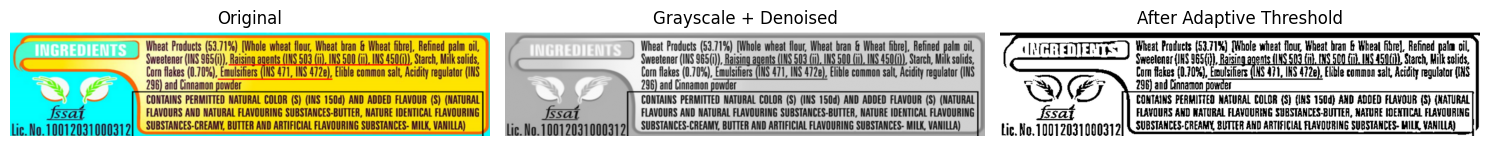


🔍 Stage 2: Reading text from image...


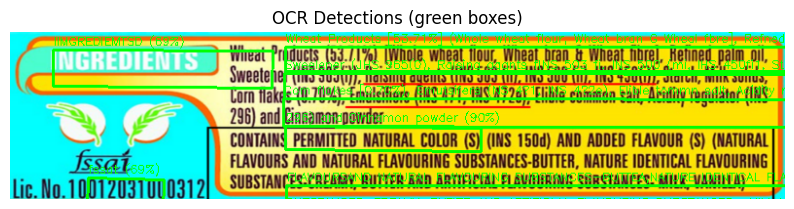


Detected 9 text regions
Raw OCR text:
IIMGREDIEMTSD Wheat Products [53.71%] (Whole wheat flour, Wheat bran G Wheal fbre], Refned pala ail. Sweelener (JHS 965(0), Raising aggnts fINS 503 fi. INS 500 (mi, IHS 450fi1, Stareh, Milk solids Com flakes [0.70%), Emutsifers (NS 4?1, INS 4?2e), Elible tommn salt, Acidity regulator (tNS 296) and Cinnamon powder fssat FLAVOURSAND NATURAL FLAVOURING SUBSTANCES-BUTTEA,NATURE IDENTICAL FLAVOURING Lic.No.10012031000312 SUBSTANCES-EREAMY, BUTIER AND ARTIFICLAL FLAVOURING SUBSTANCES- HILL VANIULA)

🏷️  Detected panel type: INGREDIENTS

📝 Stage 4a: Parsing ingredients...

Parsed 6 ingredients + 0 E-numbers
Ingredients: ['iimgrediemtsd wheat products', 'raising aggnts fins 503 fi', 'ins', 'elible tommn salt', 'nature identical flavouring lic', 'substances-ereamy']
E-numbers  : []

🔗 Stage 4b: Matching against known ingredients...

MATCHED INGREDIENTS (6/6)
  iimgrediemtsd wheat products   → wheat                     (90%) 
  raising aggnts fins 503 fi   

In [25]:
# ========== CHANGE THIS PATH TO YOUR IMAGE ==========
IMAGE_PATH = r"D:\nutri_score\img4.png"
# =====================================================

result = scan_food_packet(IMAGE_PATH)